# Semiempirical simulation of landslide runout

© 2026 Exneyder A. Montoya-Araque, Daniel F. Ruiz y Universidad EAFIT.

This notebook can be interactively run in [Google - Colab](https://colab.research.google.com/github/AppliedMechanics-EAFIT/EAFIT_slope_stability/blob/main/notebooks/04_propagation/runout_semiempirical.ipynb).

This notebook implements the semiempirical simulation tool to  estimate runout and intensity of gravitational mass flows ``Flow-Py v1.0`` develped by {cite:t}`DAmboise_etal_2022_FlowPyV10Customizable`.

## Modules and global setup

In [ ]:
import os
import requests
import shutil

if 'google.colab' in str(get_ipython()):
    from google.colab import files
    print('Running on CoLab. Installing the required modules...')
    from subprocess import run
    # run('pip install ipympl', shell=True);
    run('pip install geotoolbox', shell=True);
else:
    import tkinter as tk
    from tkinter.filedialog import askopenfilename

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import rasterio
import geotoolbox as gt
from geotoolbox.flowpy.main import run_flowpy

# Figures setup
# %matplotlib widget
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "cmr", "cmr10", "DejaVu Serif"],  # or 
    "mathtext.fontset": "cm",  # Use Computer Modern fonts for math
    "axes.formatter.use_mathtext": True,  # Use mathtext for axis labels
    "axes.unicode_minus": False,   # Use standard minus sign instead of a unicode character
})


## Input data
If working on Google Colab, set the `testing_data` variable in the following cell as `False`. Then you will be asked to upload your own raster files.

In [ ]:
testing_data = True  # Set to False to use the GUI to load the data from an external file

### Digital elevation model

In [ ]:
working_dir = "./data/"
os.makedirs(working_dir, exist_ok=True)
path2dem = os.path.join(working_dir, "DEM.tif")

if testing_data:
    url = "https://github.com/eamontoyaa/data4testing/raw/main/runout/DEM.tif"
    response = requests.get(url)
    with open("./data/DEM.tif", "wb") as f:
        f.write(response.content)
else:
    uploaded = files.upload()  # sube el archivo
    for filename in uploaded.keys():
        shutil.move(filename, "./data/DEM.tif")
        print("Archivo movido a ./data/DEM.tif")

DEM, transform_DEM, bounds_DEM, crs_DEM, nodata_DEM = gt.sig_helper.load_raster(path2dem)

# Extent
extent = (bounds_DEM.left, bounds_DEM.right, bounds_DEM.bottom, bounds_DEM.top)
# Hillshade
HSD = gt.sig_helper.get_hillshade(DEM, azimuth=315, altitude=35, cellsize=transform_DEM[0])

### Release areas and visualization

In [13]:
# Define the sources coordinates (in the same CRS as the DEM)

sources_coords = [
    (4706108.2, 2243465.6),
    (4706145.7, 2243415.7),
]

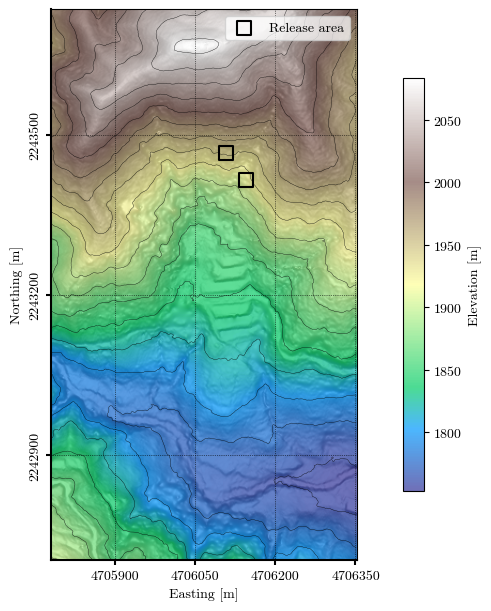

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), layout="constrained")

ax.imshow(HSD, cmap='Greys', alpha=.75, extent=extent)
im = ax.imshow(DEM, cmap='terrain', alpha=0.7, extent=extent)
cbar_elev = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.05, orientation='vertical', label='Elevation [m]')
ax.contour(DEM, levels=20, colors='k', linewidths=0.25, alpha=1, extent=extent, origin='upper')

ax.scatter(*zip(*sources_coords), marker='s', s=100, c='none', edgecolor='k', lw=1.5, label='Release area')
ax.legend(loc='upper right', framealpha=0.75)

ax.grid(True, ls=':', lw=0.5, color='k')
# ax.set_xlim((extent[0], 4701450))
ax.spines[["bottom", "left"]].set_linewidth(1.5)
ax.set_xlabel('Easting [m]')
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=False))
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))
ax.ticklabel_format(style='plain', axis='x')
ax.set_ylabel('Northing [m]')
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='y')  # or axis='x'
plt.setp(ax.get_yticklabels(), rotation=90, ha='right', va='center')
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))
ax.tick_params(width=1.5)

fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()


### Saving the release areas into a tif file

In [15]:
# Indices of the source cells
row, col = rasterio.transform.rowcol(transform_DEM, *sources_coords[0])

# Create an empty array (all zeros)
height, width = DEM.shape
sources_array = np.zeros((height, width), dtype=np.int16)

# Convert (x, y) to raster indices and set them to 1
for x, y in sources_coords:
    try:
        row, col = rasterio.transform.rowcol(transform_DEM, x, y)
        if 0 <= row < height and 0 <= col < width:
            sources_array[row, col] = 1
    except Exception as e:
        print(f"Skipping point ({x}, {y}) due to error: {e}")

# path2sources = os.path.join(propagation_dir, "sources.tif")
path2sources = os.path.join(working_dir, "sources.tif")

# Save the sources array as a raster file
gt.sig_helper.save_raster(
    path2sources,
    sources_array,
    crs=crs_DEM,
    transform=transform_DEM,
    format='tif',
)


## Runing a case

In [16]:
working_dir, path2sources, path2dem

('./data/', './data/sources.tif', './data/DEM.tif')

In [17]:
flux, z_delta, fp_ta, sl_ta, cell_counts, z_delta_sum, backcalc  = run_flowpy(
    alpha=12.0,  # Reach angle in degrees → Controls the maximum runout distance
    exponent=5.0,  # Exponent coefficient → Controls controls the lateral spreading of the flow
    working_dir=working_dir,
    dem_path=path2dem,
    release_path=path2sources,
    flux_threshold=0.001,  # Together with exponent, controls the lateral spreading of the flow
    max_z=270.0  # Max Zdelta threshold (geometric measure of highest intensity in terms of Zδ)
)

# As exp → ∞ the divergence results in a single flow direction (block movement) and as exp → 1 wide spreading is encouraged (fluvial movement)
# Recomendet values for max_z: Avalanche = 270 -- Rockfall = 50 -- Soil Slide = 12

Starting...
...
DEM and Release Layer ok!
Start Tiling...
Finished Tiling...
15 Processes started and 1 calculations to perform.
Finished calculation 0_0 of 2 = 100.0%

 Time needed: 0:01:05
No output saved, set save_dir to True to save results.
Calculation finished
...


### Saving the Zmax output into a tif file

In [18]:
z_delta_plot = z_delta.copy()
z_delta_plot[z_delta_plot == 0] = np.nan

gt.sig_helper.save_raster(
    os.path.join(working_dir, "z_delta.tif"),
    z_delta_plot,
    crs=crs_DEM,
    transform=transform_DEM,
    format='tif'
)

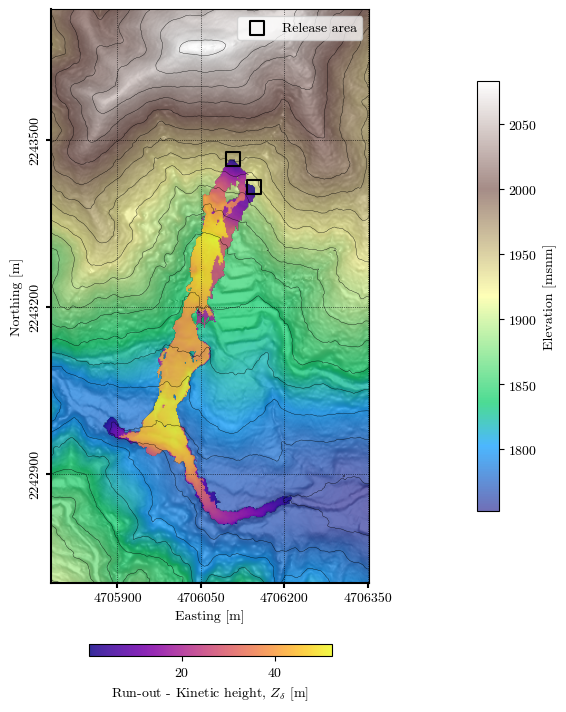

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(6, 7), layout="constrained")

ax.imshow(HSD, cmap='Greys', alpha=.75, extent=extent)
im = ax.imshow(DEM, cmap='terrain', alpha=0.7, extent=extent)
cbar_elev = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.05, orientation='vertical', label='Elevation [msnm]')
ax.contour(DEM, levels=20, colors='k', linewidths=0.25, alpha=1, extent=extent, origin='upper')


im_z_delta = ax.imshow(z_delta_plot, cmap='plasma', alpha=0.85, extent=extent)
cbar_flujos = fig.colorbar(im_z_delta, ax=ax, shrink=0.5, pad=0.03, orientation='horizontal', label='Run-out - Kinetic height, $Z_{\\delta}$ [m]')


ax.scatter(*zip(*sources_coords), marker='s', s=100, c='none', edgecolor='k', lw=1.5, label='Release area')
ax.legend(loc='upper right', framealpha=0.75)

ax.grid(True, ls=':', lw=0.5, color='k')
# ax.set_xlim((extent[0], 4701450))
ax.spines[["bottom", "left"]].set_linewidth(1.5)
ax.set_xlabel('Easting [m]')
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=False))
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))
ax.ticklabel_format(style='plain', axis='x')
ax.set_ylabel('Northing [m]')
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='y')  # or axis='x'
plt.setp(ax.get_yticklabels(), rotation=90, ha='right', va='center')
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))
ax.tick_params(width=1.5)

fig.canvas.header_visible = False
fig.canvas.toolbar_position = 'bottom'
plt.show()